# Emotion Classification System

Build an end-to-end multiclass emotion classifier for six Ekman emotions:
**anger, disgust, fear, joy, sadness, and surprise**.

The project uses the official GoEmotions Ekman mapping, pre-trained GloVe
embeddings, three custom sequence models, a fine-tuned DistilBERT model,
per-class evaluation, confusion matrices, attention heatmaps, checkpoint
saving, and prediction on new text.

## 1. Imports and Configuration

In [35]:
from pathlib import Path
from collections import Counter
import html
import json
import math
import random
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from datasets import (
    DatasetDict,
    concatenate_datasets,
    load_dataset,
    load_from_disk,
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import DataLoader, Dataset, Sampler
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainerCallback,
    TrainingArguments,
    get_linear_schedule_with_warmup,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 140)
sns.set_theme(style='whitegrid')

PROJECT_DIR = Path.cwd().resolve()
DATA_DIR = PROJECT_DIR / 'data'
DATASET_DIR = DATA_DIR / 'goemotions_six'
CSV_DIR = DATA_DIR / 'goemotions_six_csv'
STRATIFIED_DATASET_DIR = (
    DATA_DIR / 'goemotions_six_stratified_train_validation'
)
STRATIFIED_CSV_DIR = (
    DATA_DIR / 'goemotions_six_stratified_train_validation_csv'
)
HF_CACHE_DIR = PROJECT_DIR / 'hf_cache'
EMBEDDINGS_DIR = PROJECT_DIR / 'embeddings'
CHECKPOINT_DIR = PROJECT_DIR / 'checkpoints'
GLOVE_PATH = EMBEDDINGS_DIR / 'glove.6B.300d.txt'

for directory in [
    DATA_DIR,
    CSV_DIR,
    STRATIFIED_CSV_DIR,
    HF_CACHE_DIR,
    EMBEDDINGS_DIR,
    CHECKPOINT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

TARGET_EMOTIONS = ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']
NUM_CLASSES = len(TARGET_EMOTIONS)
id2label = {index: emotion for index, emotion in enumerate(TARGET_EMOTIONS)}
label2id = {emotion: index for index, emotion in id2label.items()}

# Official GoEmotions mapping to Ekman's six basic emotions.
EKMAN_MAPPING = {
    'anger': ['anger', 'annoyance', 'disapproval'],
    'disgust': ['disgust'],
    'fear': ['fear', 'nervousness'],
    'joy': [
        'joy', 'amusement', 'approval', 'excitement', 'gratitude',
        'love', 'optimism', 'relief', 'pride', 'admiration',
        'desire', 'caring',
    ],
    'sadness': ['sadness', 'disappointment', 'embarrassment', 'grief', 'remorse'],
    'surprise': ['surprise', 'realization', 'confusion', 'curiosity'],
}

SAMPLING_HYPERPARAMS = {
    'use_stratified_splits': True,
    'strategy': 'dynamic_rotating_undersampling',
    'samples_per_class': 'minority',
    'shuffle_each_epoch': True,
}

CUSTOM_HYPERPARAMS = {
    'tokenizer_model': 'facebook/bart-base',
    'vocab_size': 50265,
    'embedding_dim': 300,
    'hidden_size': 256,
    'num_layers': 2,
    'batch_size': 128,
    'max_sequence_length': 64,
    'learning_rate': 1e-3,
    'max_epochs': 100,
    'dropout': 0.3,
    'weight_decay': 1e-4,
    'gradient_clip': 1.0,
    'early_stopping_patience': 3,
    'min_improvement': 0.001,
    'freeze_embeddings': False,
}

TRANSFORMER_HYPERPARAMS = {
    'base_model': 'distilbert-base-uncased',
    'max_length': 128,
    'batch_size': 32,
    'learning_rate': 2e-5,
    'weight_decay': 0.01,
    'max_epochs': 100,
    'warmup_ratio': 0.1,
    'early_stopping_patience': 2,
    'mixed_precision_amp': True,
    'optimizer': 'AdamW',
}

print(f'Project directory: {PROJECT_DIR}')
print(f'Device: {DEVICE}')
print(f'Target emotions: {TARGET_EMOTIONS}')

Project directory: D:\NLP_INSTANT\Emotion Classification Project
Device: cuda
Target emotions: ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']


## 2. Load, Map, and Stratify GoEmotions

Load the simplified GoEmotions splits and map the 27 fine-grained labels
to the official six-class Ekman taxonomy. A comment is retained when all
of its mapped labels agree on exactly one target class. Neutral and
cross-class ambiguous comments are excluded.

Training and validation examples are combined and split again with their
original sizes using label stratification. The official test split remains
untouched, so it stays fully held out and directly comparable with the
earlier experiment. The fixed random seed makes the split reproducible.

In [36]:
def map_goemotions_to_six(raw_dataset):
    fine_label_names = raw_dataset['train'].features['labels'].feature.names
    fine_to_target = {
        fine_label: label2id[target]
        for target, fine_labels in EKMAN_MAPPING.items()
        for fine_label in fine_labels
    }

    def collect_target_labels(example):
        mapped = {
            fine_to_target[fine_label_names[label_id]]
            for label_id in example['labels']
            if fine_label_names[label_id] in fine_to_target
        }
        return {'mapped_labels': sorted(mapped)}

    mapped_dataset = raw_dataset.map(collect_target_labels)
    mapped_dataset = mapped_dataset.filter(
        lambda example: len(example['mapped_labels']) == 1
    )
    mapped_dataset = mapped_dataset.map(
        lambda example: {
            'label': example['mapped_labels'][0],
            'emotion': id2label[example['mapped_labels'][0]],
        }
    )
    return mapped_dataset.remove_columns(['labels', 'mapped_labels'])


def build_stratified_splits(mapped_dataset):
    train_validation_dataset = concatenate_datasets([
        mapped_dataset['train'],
        mapped_dataset['validation'],
    ])

    train_validation_ids = set(train_validation_dataset['id'])
    test_ids = set(mapped_dataset['test']['id'])
    if len(train_validation_ids) != len(train_validation_dataset):
        raise ValueError(
            'Duplicate IDs found in the train-validation pool.'
        )
    if train_validation_ids.intersection(test_ids):
        raise ValueError(
            'The official test split overlaps the training data.'
        )

    all_indices = np.arange(len(train_validation_dataset))
    all_labels = np.asarray(
        train_validation_dataset['label'],
        dtype=np.int64,
    )
    train_indices, validation_indices = train_test_split(
        all_indices,
        test_size=len(mapped_dataset['validation']),
        random_state=RANDOM_SEED,
        shuffle=True,
        stratify=all_labels,
    )

    return DatasetDict({
        'train': train_validation_dataset.select(
            train_indices.tolist()
        ),
        'validation': train_validation_dataset.select(
            validation_indices.tolist()
        ),
        'test': mapped_dataset['test'],
    })

if DATASET_DIR.exists():
    mapped_dataset = load_from_disk(str(DATASET_DIR))
else:
    raw_dataset = load_dataset(
        'google-research-datasets/go_emotions',
        'simplified',
        cache_dir=str(HF_CACHE_DIR),
    )
    mapped_dataset = map_goemotions_to_six(raw_dataset)
    mapped_dataset.save_to_disk(str(DATASET_DIR))
    for split_name, split_dataset in mapped_dataset.items():
        split_dataset.to_csv(
            str(CSV_DIR / f'{split_name}.csv'),
            index=False,
        )

if SAMPLING_HYPERPARAMS['use_stratified_splits']:
    if STRATIFIED_DATASET_DIR.exists():
        dataset = load_from_disk(str(STRATIFIED_DATASET_DIR))
    else:
        dataset = build_stratified_splits(mapped_dataset)
        dataset.save_to_disk(str(STRATIFIED_DATASET_DIR))
        for split_name, split_dataset in dataset.items():
            split_dataset.to_csv(
                str(STRATIFIED_CSV_DIR / f'{split_name}.csv'),
                index=False,
            )
else:
    dataset = mapped_dataset

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'id', 'label', 'emotion'],
        num_rows: 28104
    })
    validation: Dataset({
        features: ['text', 'id', 'label', 'emotion'],
        num_rows: 3527
    })
    test: Dataset({
        features: ['text', 'id', 'label', 'emotion'],
        num_rows: 3539
    })
})

## 3. Dataset Exploration and Quality Checks

In [37]:
split_summary = pd.DataFrame([
    {
        'split': split_name,
        'rows': len(split_dataset),
        'columns': len(split_dataset.column_names),
        'missing_text': sum(not str(text).strip() for text in split_dataset['text']),
        'duplicate_ids': len(split_dataset) - len(set(split_dataset['id'])),
    }
    for split_name, split_dataset in dataset.items()
])

display(split_summary)
display(pd.DataFrame(dataset['train'][:8]))

,split,rows,columns,missing_text,duplicate_ids
0,train,28104,4,0,0
1,validation,3527,4,0,0
2,test,3539,4,0,0


,text,id,label,emotion
0,[NAME] gave me depression because had I been left unchecked I would have bested him in hand to hand combat by age 16,ef91uq5,4,sadness
1,Must not have been the [NAME] of his day... But seriously though i hope he's alright..,ef1uso1,3,joy
2,"Dude, y'all anti American scum don't even believe in science. Fuck off with your generic bullshit because you can't list a specific exam...",ee9zewu,0,anger
3,“You fight like my sister!” “I’ve fought your sister! That’s a compliment!”,eff3lfj,3,joy
4,"Sorry, doesn't ring a bell. Do.you know [NAME] ign?",edsn7k9,3,joy
5,"Guys help I can’t stop playing it, my hands are in so much pain!",eed6rhp,4,sadness
6,UNCLE RADITZ IS PISSED!!!,efcqelt,0,anger
7,Still very curious who this woman is and what she looks like,edkw0d4,5,surprise


,emotion,count,percentage
0,anger,5795,16.48%
1,disgust,663,1.89%
2,fear,728,2.07%
3,joy,19763,56.19%
4,sadness,3031,8.62%
5,surprise,5190,14.76%


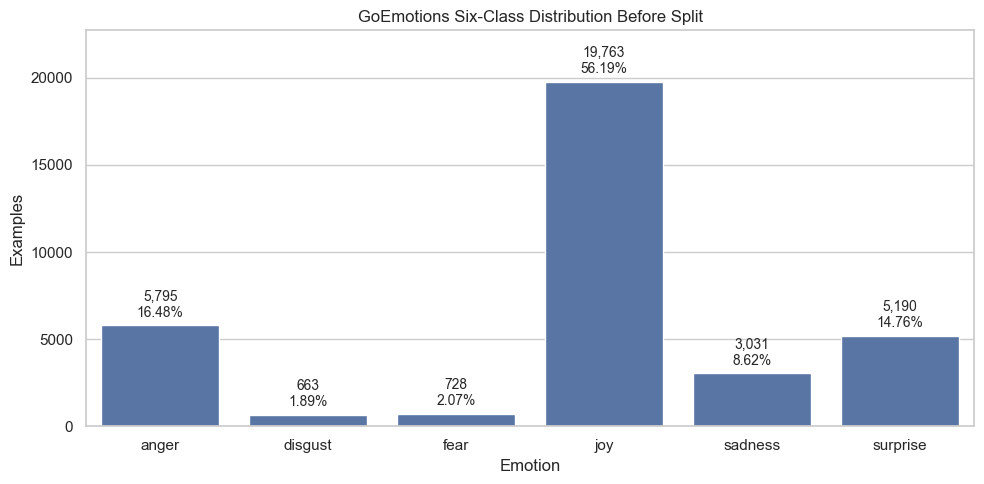

In [38]:
before_split_dataset = mapped_dataset if 'mapped_dataset' in globals() else dataset
before_split_all = concatenate_datasets([
    before_split_dataset[split_name]
    for split_name in before_split_dataset.keys()
])

before_split_counts = Counter(before_split_all['emotion'])
before_split_distribution_df = pd.DataFrame([
    {
        'emotion': emotion,
        'count': before_split_counts.get(emotion, 0),
    }
    for emotion in TARGET_EMOTIONS
])
before_split_total = before_split_distribution_df['count'].sum()
before_split_distribution_df['percentage'] = (
    before_split_distribution_df['count'] / before_split_total * 100
)

display(
    before_split_distribution_df.assign(
        percentage=before_split_distribution_df['percentage'].map(lambda value: f'{value:.2f}%')
    )
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=before_split_distribution_df,
    x='emotion',
    y='count',
    color=sns.color_palette()[0],
)

for bar, (_, row) in zip(ax.patches, before_split_distribution_df.iterrows()):
    ax.annotate(
        f"{int(row['count']):,}\n{row['percentage']:.2f}%",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(0, 4),
        textcoords='offset points',
    )

plt.title('GoEmotions Six-Class Distribution Before Split')
plt.xlabel('Emotion')
plt.ylabel('Examples')
plt.ylim(0, before_split_distribution_df['count'].max() * 1.15)
plt.tight_layout()
plt.show()


split,test,train,validation
emotion,,,
anger,609,4608,578
disgust,77,521,65
fear,85,571,72
joy,1937,15838,1988
sadness,298,2428,305
surprise,533,4138,519


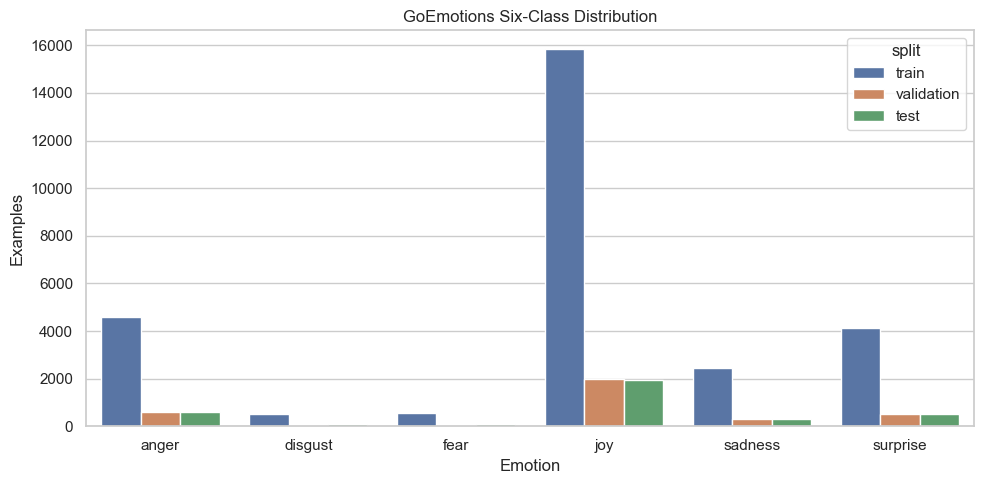

In [39]:
distribution_rows = []
for split_name, split_dataset in dataset.items():
    counts = Counter(split_dataset['emotion'])
    for emotion in TARGET_EMOTIONS:
        distribution_rows.append({
            'split': split_name,
            'emotion': emotion,
            'count': counts.get(emotion, 0),
        })

distribution_df = pd.DataFrame(distribution_rows)
display(distribution_df.pivot(index='emotion', columns='split', values='count'))

plt.figure(figsize=(10, 5))
sns.barplot(data=distribution_df, x='emotion', y='count', hue='split')
plt.title('GoEmotions Six-Class Distribution')
plt.xlabel('Emotion')
plt.ylabel('Examples')
plt.tight_layout()
plt.show()

## 4. BART Tokenization and Padding

Use the BART tokenizer for the custom LSTM, GRU, and BiLSTM + Attention
models. Sequences are truncated to the custom-model maximum length, then
padded inside the PyTorch dataset.

In [40]:
custom_tokenizer = AutoTokenizer.from_pretrained(
    CUSTOM_HYPERPARAMS['tokenizer_model']
)

PAD_ID = custom_tokenizer.pad_token_id
UNK_ID = custom_tokenizer.unk_token_id
if PAD_ID is None:
    raise ValueError('The custom tokenizer must define a padding token.')
if UNK_ID is None:
    UNK_ID = PAD_ID

vocab = custom_tokenizer.get_vocab()
id2custom_token = {
    token_id: token
    for token, token_id in vocab.items()
}


def tokenize_custom_batch(batch):
    encoded = custom_tokenizer(
        batch['text'],
        truncation=True,
        max_length=CUSTOM_HYPERPARAMS['max_sequence_length'],
        add_special_tokens=True,
    )
    lengths = [len(input_ids) for input_ids in encoded['input_ids']]
    tokens = [
        custom_tokenizer.convert_ids_to_tokens(input_ids)
        for input_ids in encoded['input_ids']
    ]
    return {
        'input_ids': encoded['input_ids'],
        'attention_mask': encoded['attention_mask'],
        'tokens': tokens,
        'length': lengths,
    }


processed_dataset = dataset.map(tokenize_custom_batch, batched=True)

token_lengths = np.array(processed_dataset['train']['length'])
print(f'Custom tokenizer: {CUSTOM_HYPERPARAMS["tokenizer_model"]}')
print(f'Vocabulary size: {len(vocab):,}')
print(f'PAD token/id: {custom_tokenizer.pad_token!r} / {PAD_ID}')
print(f'UNK token/id: {custom_tokenizer.unk_token!r} / {UNK_ID}')
print(f'Median tokens: {np.median(token_lengths):.0f}')
print(f'95th percentile: {np.percentile(token_lengths, 95):.0f}')
print(f'Maximum sequence length: {CUSTOM_HYPERPARAMS["max_sequence_length"]}')

Custom tokenizer: facebook/bart-base
Vocabulary size: 50,265
PAD token/id: '<pad>' / 1
UNK token/id: '<unk>' / 3
Median tokens: 18
95th percentile: 33
Maximum sequence length: 64


In [41]:
class EmotionSequenceDataset(Dataset):
    def __init__(self, split_dataset, max_length):
        self.dataset = split_dataset
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        example = self.dataset[index]
        token_ids = example['input_ids'][:self.max_length]
        if not token_ids:
            token_ids = [UNK_ID]
        length = len(token_ids)
        token_ids += [PAD_ID] * (self.max_length - length)
        return {
            'input_ids': torch.tensor(token_ids, dtype=torch.long),
            'length': torch.tensor(length, dtype=torch.long),
            'label': torch.tensor(example['label'], dtype=torch.long),
        }


class RotatingUndersampler(Sampler):
    def __init__(
        self,
        labels,
        samples_per_class='minority',
        seed=RANDOM_SEED,
        shuffle=True,
    ):
        self.labels = np.asarray(labels, dtype=np.int64)
        self.seed = seed
        self.shuffle = shuffle
        self.epoch = 0

        counts = np.bincount(self.labels, minlength=NUM_CLASSES)
        non_empty_counts = counts[counts > 0]
        if len(non_empty_counts) != NUM_CLASSES:
            missing = [
                TARGET_EMOTIONS[class_id]
                for class_id, count in enumerate(counts)
                if count == 0
            ]
            raise ValueError(f'Missing classes in training labels: {missing}')

        if samples_per_class == 'minority':
            self.samples_per_class = int(non_empty_counts.min())
        else:
            self.samples_per_class = int(samples_per_class)
            if self.samples_per_class <= 0:
                raise ValueError('samples_per_class must be positive.')
            self.samples_per_class = min(
                self.samples_per_class,
                int(non_empty_counts.min()),
            )

        rng = np.random.default_rng(seed)
        self.class_indices = []
        for class_id in range(NUM_CLASSES):
            indices = np.flatnonzero(self.labels == class_id)
            self.class_indices.append(rng.permutation(indices).tolist())

    def __iter__(self):
        epoch_indices = []
        for indices in self.class_indices:
            start = (self.epoch * self.samples_per_class) % len(indices)
            stop = start + self.samples_per_class
            if stop <= len(indices):
                selected = indices[start:stop]
            else:
                selected = indices[start:] + indices[:stop - len(indices)]
            epoch_indices.extend(selected)

        if self.shuffle:
            rng = np.random.default_rng(self.seed + self.epoch)
            rng.shuffle(epoch_indices)

        self.epoch += 1
        return iter(epoch_indices)

    def __len__(self):
        return self.samples_per_class * NUM_CLASSES


custom_datasets = {
    split_name: EmotionSequenceDataset(
        split_dataset,
        CUSTOM_HYPERPARAMS['max_sequence_length'],
    )
    for split_name, split_dataset in processed_dataset.items()
}

train_labels = np.asarray(
    processed_dataset['train']['label'],
    dtype=np.int64,
)
train_counts = np.bincount(train_labels, minlength=NUM_CLASSES)
minority_train_count = int(train_counts.min())
dynamic_undersample_epoch_size = minority_train_count * NUM_CLASSES
rotation_epochs_to_cover_class = np.ceil(
    train_counts / minority_train_count
).astype(int)


def make_rotating_undersampler(labels, seed=RANDOM_SEED):
    return RotatingUndersampler(
        labels,
        samples_per_class=SAMPLING_HYPERPARAMS['samples_per_class'],
        seed=seed,
        shuffle=SAMPLING_HYPERPARAMS['shuffle_each_epoch'],
    )


def make_custom_train_loader(seed=RANDOM_SEED):
    return DataLoader(
        custom_datasets['train'],
        batch_size=CUSTOM_HYPERPARAMS['batch_size'],
        sampler=make_rotating_undersampler(train_labels, seed=seed),
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )


custom_loaders = {
    'validation': DataLoader(
        custom_datasets['validation'],
        batch_size=CUSTOM_HYPERPARAMS['batch_size'],
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    ),
    'test': DataLoader(
        custom_datasets['test'],
        batch_size=CUSTOM_HYPERPARAMS['batch_size'],
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    ),
}

sampling_summary = pd.DataFrame({
    'emotion': TARGET_EMOTIONS,
    'train_count': train_counts,
    'train_proportion': train_counts / train_counts.sum(),
    'samples_per_epoch': minority_train_count,
    'epoch_proportion': np.repeat(1 / NUM_CLASSES, NUM_CLASSES),
    'rotation_epochs_to_cover_class': rotation_epochs_to_cover_class,
})
sampling_summary

,emotion,train_count,train_proportion,samples_per_epoch,epoch_proportion,rotation_epochs_to_cover_class
0,anger,4608,0.163962,521,0.166667,9
1,disgust,521,0.018538,521,0.166667,1
2,fear,571,0.020317,521,0.166667,2
3,joy,15838,0.563550,521,0.166667,31
4,sadness,2428,0.086393,521,0.166667,5
5,surprise,4138,0.147239,521,0.166667,8


## 5. Load Pre-trained GloVe Embeddings

Create an embedding matrix aligned with the BART tokenizer vocabulary. BART
subword tokens that normalize to GloVe words receive matching vectors; all
other non-padding tokens keep small random vectors.

In [42]:
def normalize_bart_token_for_glove(token):
    if token in custom_tokenizer.all_special_tokens:
        return None
    token = token.replace('\u0120', '').replace('\u010a', '').lower().strip()
    token = re.sub(r"^[^a-z']+|[^a-z']+$", '', token)
    if not token or not re.fullmatch(r"[a-z]+(?:'[a-z]+)?", token):
        return None
    return token


def build_glove_embedding_matrix(vocabulary, glove_path, embedding_dim):
    glove_path = Path(glove_path)
    if not glove_path.exists():
        raise FileNotFoundError(
            f'GloVe file not found: {glove_path}. '
            'Place glove.6B.300d.txt inside the embeddings folder.'
        )

    matrix = np.random.normal(
        0,
        0.05,
        size=(len(vocabulary), embedding_dim),
    ).astype(np.float32)
    matrix[PAD_ID] = np.zeros(embedding_dim, dtype=np.float32)

    candidate_to_token_ids = {}
    special_ids = set(custom_tokenizer.all_special_ids)
    for token, token_id in vocabulary.items():
        if token_id in special_ids:
            continue
        candidate = normalize_bart_token_for_glove(token)
        if candidate is None:
            continue
        candidate_to_token_ids.setdefault(candidate, []).append(token_id)

    found_token_ids = set()
    with glove_path.open('r', encoding='utf-8', errors='ignore') as glove_file:
        for line in glove_file:
            parts = line.rstrip().split()
            if len(parts) != embedding_dim + 1:
                continue
            token_ids = candidate_to_token_ids.get(parts[0])
            if token_ids is None:
                continue
            vector = np.asarray(parts[1:], dtype=np.float32)
            for token_id in token_ids:
                matrix[token_id] = vector
                found_token_ids.add(token_id)

    coverage_denominator = max(len(vocabulary) - len(special_ids), 1)
    coverage = len(found_token_ids) / coverage_denominator
    print(
        f'Loaded {len(found_token_ids):,}/{len(vocabulary):,} BART-token '
        f'GloVe vectors ({coverage:.2%} coverage).'
    )
    return torch.tensor(matrix, dtype=torch.float32), coverage


pretrained_embedding_matrix, glove_coverage = build_glove_embedding_matrix(
    vocab,
    GLOVE_PATH,
    CUSTOM_HYPERPARAMS['embedding_dim'],
)

{
    'path': str(GLOVE_PATH),
    'tokenizer': CUSTOM_HYPERPARAMS['tokenizer_model'],
    'shape': tuple(pretrained_embedding_matrix.shape),
    'coverage': glove_coverage,
    'freeze_embeddings': CUSTOM_HYPERPARAMS['freeze_embeddings'],
}

Loaded 41,177/50,265 BART-token GloVe vectors (81.93% coverage).


{'path': 'D:\\NLP_INSTANT\\Emotion Classification Project\\embeddings\\glove.6B.300d.txt',
 'tokenizer': 'facebook/bart-base',
 'shape': (50265, 300),
 'coverage': 0.8192797453243136,
 'freeze_embeddings': False}

## 6. LSTM, GRU, and BiLSTM + Attention Models

In [43]:
def make_pretrained_embedding():
    return nn.Embedding.from_pretrained(
        pretrained_embedding_matrix.clone(),
        freeze=CUSTOM_HYPERPARAMS['freeze_embeddings'],
        padding_idx=PAD_ID,
    )

class LSTMClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = make_pretrained_embedding()
        self.dropout = nn.Dropout(CUSTOM_HYPERPARAMS['dropout'])
        self.encoder = nn.LSTM(
            input_size=CUSTOM_HYPERPARAMS['embedding_dim'],
            hidden_size=CUSTOM_HYPERPARAMS['hidden_size'],
            num_layers=CUSTOM_HYPERPARAMS['num_layers'],
            batch_first=True,
            dropout=CUSTOM_HYPERPARAMS['dropout'],
        )
        self.classifier = nn.Linear(
            CUSTOM_HYPERPARAMS['hidden_size'],
            NUM_CLASSES,
        )

    def forward(self, input_ids, lengths):
        embedded = self.dropout(self.embedding(input_ids))
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden, _) = self.encoder(packed)
        return self.classifier(self.dropout(hidden[-1]))

class GRUClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = make_pretrained_embedding()
        self.dropout = nn.Dropout(CUSTOM_HYPERPARAMS['dropout'])
        self.encoder = nn.GRU(
            input_size=CUSTOM_HYPERPARAMS['embedding_dim'],
            hidden_size=CUSTOM_HYPERPARAMS['hidden_size'],
            num_layers=CUSTOM_HYPERPARAMS['num_layers'],
            batch_first=True,
            dropout=CUSTOM_HYPERPARAMS['dropout'],
        )
        self.classifier = nn.Linear(
            CUSTOM_HYPERPARAMS['hidden_size'],
            NUM_CLASSES,
        )

    def forward(self, input_ids, lengths):
        embedded = self.dropout(self.embedding(input_ids))
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, hidden = self.encoder(packed)
        return self.classifier(self.dropout(hidden[-1]))

class BiLSTMAttentionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = make_pretrained_embedding()
        self.dropout = nn.Dropout(CUSTOM_HYPERPARAMS['dropout'])
        self.encoder = nn.LSTM(
            input_size=CUSTOM_HYPERPARAMS['embedding_dim'],
            hidden_size=CUSTOM_HYPERPARAMS['hidden_size'],
            num_layers=CUSTOM_HYPERPARAMS['num_layers'],
            batch_first=True,
            bidirectional=True,
            dropout=CUSTOM_HYPERPARAMS['dropout'],
        )
        encoded_size = CUSTOM_HYPERPARAMS['hidden_size'] * 2
        self.attention = nn.Linear(encoded_size, 1)
        self.classifier = nn.Linear(encoded_size, NUM_CLASSES)

    def forward(self, input_ids, lengths, return_attention=False):
        embedded = self.dropout(self.embedding(input_ids))
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_output, _ = self.encoder(packed)
        encoded, _ = pad_packed_sequence(
            packed_output,
            batch_first=True,
            total_length=input_ids.size(1),
        )

        mask = input_ids.ne(PAD_ID)
        scores = self.attention(torch.tanh(encoded)).squeeze(-1)
        scores = scores.masked_fill(~mask, torch.finfo(scores.dtype).min)
        attention_weights = torch.softmax(scores, dim=1)
        context = torch.sum(encoded * attention_weights.unsqueeze(-1), dim=1)
        logits = self.classifier(self.dropout(context))

        if return_attention:
            return logits, attention_weights
        return logits

lstm_model = LSTMClassifier().to(DEVICE)
gru_model = GRUClassifier().to(DEVICE)
bilstm_attention_model = BiLSTMAttentionClassifier().to(DEVICE)

lstm_optimizer = torch.optim.AdamW(
    lstm_model.parameters(),
    lr=CUSTOM_HYPERPARAMS['learning_rate'],
    weight_decay=CUSTOM_HYPERPARAMS['weight_decay'],
)
gru_optimizer = torch.optim.AdamW(
    gru_model.parameters(),
    lr=CUSTOM_HYPERPARAMS['learning_rate'],
    weight_decay=CUSTOM_HYPERPARAMS['weight_decay'],
)
bilstm_attention_optimizer = torch.optim.AdamW(
    bilstm_attention_model.parameters(),
    lr=CUSTOM_HYPERPARAMS['learning_rate'],
    weight_decay=CUSTOM_HYPERPARAMS['weight_decay'],
)

# Dynamic undersampling balances each training epoch, so the loss stays unweighted.
custom_loss = nn.CrossEntropyLoss()

lstm_model, gru_model, bilstm_attention_model

(LSTMClassifier(
   (embedding): Embedding(50265, 300, padding_idx=1)
   (dropout): Dropout(p=0.3, inplace=False)
   (encoder): LSTM(300, 256, num_layers=2, batch_first=True, dropout=0.3)
   (classifier): Linear(in_features=256, out_features=6, bias=True)
 ),
 GRUClassifier(
   (embedding): Embedding(50265, 300, padding_idx=1)
   (dropout): Dropout(p=0.3, inplace=False)
   (encoder): GRU(300, 256, num_layers=2, batch_first=True, dropout=0.3)
   (classifier): Linear(in_features=256, out_features=6, bias=True)
 ),
 BiLSTMAttentionClassifier(
   (embedding): Embedding(50265, 300, padding_idx=1)
   (dropout): Dropout(p=0.3, inplace=False)
   (encoder): LSTM(300, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
   (attention): Linear(in_features=512, out_features=1, bias=True)
   (classifier): Linear(in_features=512, out_features=6, bias=True)
 ))

## 7. Dynamic/Rotating Undersampled Custom Training and Checkpoint Saving

Each custom model receives a deterministic dynamic undersampled training
stream. Every epoch uses the same number of examples from each emotion,
matching the minority class count, while majority-class examples rotate
across epochs. Validation and test data remain untouched.

In [44]:
def save_custom_checkpoint(
    model_name,
    model,
    optimizer,
    epoch,
    history,
    best_valid_f1,
    patience_counter,
    is_best=False,
):
    checkpoint = {
        'model_name': model_name,
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
        'best_valid_f1': best_valid_f1,
        'patience_counter': patience_counter,
        'vocab': vocab,
        'custom_tokenizer_name': CUSTOM_HYPERPARAMS['tokenizer_model'],
        'id2label': id2label,
        'label2id': label2id,
        'hyperparameters': CUSTOM_HYPERPARAMS,
        'sampling_hyperparameters': SAMPLING_HYPERPARAMS,
        'glove_coverage': glove_coverage,
    }
    suffix = 'best' if is_best else 'last'
    path = CHECKPOINT_DIR / f'{model_name}_{suffix}.pt'
    torch.save(checkpoint, path)
    return path

def evaluate_custom_model(model, data_loader):
    model.eval()
    losses = []
    all_labels = []
    all_predictions = []

    with torch.inference_mode():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            lengths = batch['length']
            labels = batch['label'].to(DEVICE)
            logits = model(input_ids, lengths)
            losses.append(custom_loss(logits, labels).item())
            all_labels.extend(labels.cpu().tolist())
            all_predictions.extend(torch.argmax(logits, dim=1).cpu().tolist())

    metrics = {
        'loss': float(np.mean(losses)),
        'accuracy': accuracy_score(all_labels, all_predictions),
        'macro_f1': f1_score(
            all_labels,
            all_predictions,
            labels=list(range(NUM_CLASSES)),
            average='macro',
            zero_division=0,
        ),
        'macro_precision': precision_score(
            all_labels,
            all_predictions,
            labels=list(range(NUM_CLASSES)),
            average='macro',
            zero_division=0,
        ),
        'macro_recall': recall_score(
            all_labels,
            all_predictions,
            labels=list(range(NUM_CLASSES)),
            average='macro',
            zero_division=0,
        ),
        'labels': all_labels,
        'predictions': all_predictions,
        'confusion_matrix': confusion_matrix(
            all_labels,
            all_predictions,
            labels=list(range(NUM_CLASSES)),
        ),
    }
    return metrics

def train_custom_model(model_name, model, optimizer):
    history = []
    best_valid_f1 = -1.0
    patience_counter = 0
    best_path = CHECKPOINT_DIR / f'{model_name}_best.pt'
    train_loader = make_custom_train_loader(seed=RANDOM_SEED)

    print(f'\nTraining {model_name}')
    for epoch in range(1, CUSTOM_HYPERPARAMS['max_epochs'] + 1):
        model.train()
        train_losses = []

        for batch in train_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            lengths = batch['length']
            labels = batch['label'].to(DEVICE)

            optimizer.zero_grad()
            logits = model(input_ids, lengths)
            loss = custom_loss(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(
                model.parameters(),
                CUSTOM_HYPERPARAMS['gradient_clip'],
            )
            optimizer.step()
            train_losses.append(loss.item())

        valid_metrics = evaluate_custom_model(
            model,
            custom_loaders['validation'],
        )
        epoch_result = {
            'epoch': epoch,
            'train_loss': float(np.mean(train_losses)),
            'valid_loss': valid_metrics['loss'],
            'valid_accuracy': valid_metrics['accuracy'],
            'valid_macro_f1': valid_metrics['macro_f1'],
        }
        history.append(epoch_result)

        print(
            f'{model_name} | Epoch {epoch}/'
            f'{CUSTOM_HYPERPARAMS["max_epochs"]} | '
            f'train_loss: {epoch_result["train_loss"]:.4f} | '
            f'valid_loss: {epoch_result["valid_loss"]:.4f} | '
            f'valid_accuracy: {epoch_result["valid_accuracy"]:.4f} | '
            f'valid_macro_f1: {epoch_result["valid_macro_f1"]:.4f}'
        )

        improved = (
            valid_metrics['macro_f1']
            > best_valid_f1 + CUSTOM_HYPERPARAMS['min_improvement']
        )
        if improved:
            best_valid_f1 = valid_metrics['macro_f1']
            patience_counter = 0
            save_custom_checkpoint(
                model_name,
                model,
                optimizer,
                epoch,
                history,
                best_valid_f1,
                patience_counter,
                is_best=True,
            )
        else:
            patience_counter += 1

        save_custom_checkpoint(
            model_name,
            model,
            optimizer,
            epoch,
            history,
            best_valid_f1,
            patience_counter,
            is_best=False,
        )

        if patience_counter >= CUSTOM_HYPERPARAMS['early_stopping_patience']:
            print(f'{model_name} early stopping at epoch {epoch}')
            break

    best_checkpoint = torch.load(
        best_path,
        map_location=DEVICE,
        weights_only=False,
    )
    model.load_state_dict(best_checkpoint['model_state_dict'])
    test_metrics = evaluate_custom_model(model, custom_loaders['test'])

    print(f'\n{model_name} test classification report')
    print(classification_report(
        test_metrics['labels'],
        test_metrics['predictions'],
        labels=list(range(NUM_CLASSES)),
        target_names=TARGET_EMOTIONS,
        digits=4,
        zero_division=0,
    ))

    result = {
        'model': model_name,
        'accuracy': test_metrics['accuracy'],
        'macro_precision': test_metrics['macro_precision'],
        'macro_recall': test_metrics['macro_recall'],
        'macro_f1': test_metrics['macro_f1'],
        'confusion_matrix': test_metrics['confusion_matrix'],
        'labels': test_metrics['labels'],
        'predictions': test_metrics['predictions'],
    }
    return history, result

In [45]:
custom_results = []

lstm_history, lstm_result = train_custom_model(
    'LSTM',
    lstm_model,
    lstm_optimizer,
)
custom_results.append(lstm_result)

gru_history, gru_result = train_custom_model(
    'GRU',
    gru_model,
    gru_optimizer,
)
custom_results.append(gru_result)

attention_history, attention_result = train_custom_model(
    'BiLSTM_Attention',
    bilstm_attention_model,
    bilstm_attention_optimizer,
)
custom_results.append(attention_result)

pd.DataFrame([
    {
        key: value
        for key, value in result.items()
        if key not in {'confusion_matrix', 'labels', 'predictions'}
    }
    for result in custom_results
]).sort_values('macro_f1', ascending=False)


Training LSTM
LSTM | Epoch 1/100 | train_loss: 1.7730 | valid_loss: 1.6182 | valid_accuracy: 0.4607 | valid_macro_f1: 0.2292
LSTM | Epoch 2/100 | train_loss: 1.5671 | valid_loss: 1.4979 | valid_accuracy: 0.4726 | valid_macro_f1: 0.3074
LSTM | Epoch 3/100 | train_loss: 1.3610 | valid_loss: 1.2631 | valid_accuracy: 0.5330 | valid_macro_f1: 0.4527
LSTM | Epoch 4/100 | train_loss: 1.1475 | valid_loss: 1.1443 | valid_accuracy: 0.5756 | valid_macro_f1: 0.4690
LSTM | Epoch 5/100 | train_loss: 1.0763 | valid_loss: 1.1360 | valid_accuracy: 0.5554 | valid_macro_f1: 0.5008
LSTM | Epoch 6/100 | train_loss: 1.0391 | valid_loss: 0.9562 | valid_accuracy: 0.6583 | valid_macro_f1: 0.5602
LSTM | Epoch 7/100 | train_loss: 0.9598 | valid_loss: 0.9981 | valid_accuracy: 0.6374 | valid_macro_f1: 0.5226
LSTM | Epoch 8/100 | train_loss: 0.9058 | valid_loss: 1.0565 | valid_accuracy: 0.6164 | valid_macro_f1: 0.5388
LSTM | Epoch 9/100 | train_loss: 0.8240 | valid_loss: 0.9254 | valid_accuracy: 0.6728 | valid_mac

,model,accuracy,macro_precision,macro_recall,macro_f1
2,BiLSTM_Attention,0.737214,0.616652,0.679001,0.643437
1,GRU,0.702176,0.583560,0.656564,0.611156
0,LSTM,0.712066,0.585401,0.654815,0.608415


## 8. Attention Heatmaps


Text: I was thrilled when everyone arrived for my birthday.


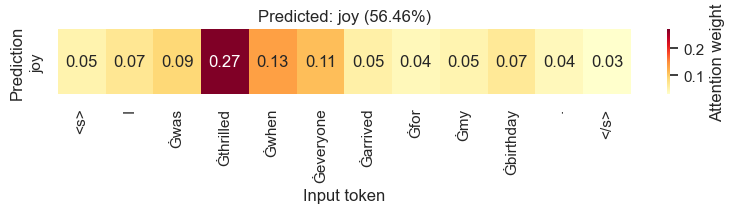

,emotion,probability
3,joy,0.564641
5,surprise,0.427542
4,sadness,0.005557
0,anger,0.001884
2,fear,0.000350
1,disgust,0.000026



Text: The strange noise outside made me extremely nervous.


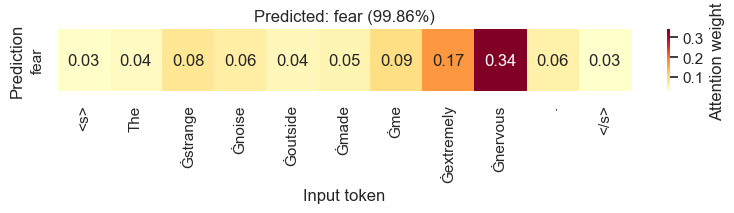

,emotion,probability
2,fear,0.998573
4,sadness,0.000547
5,surprise,0.000446
3,joy,0.000247
0,anger,0.000168
1,disgust,0.000018



Text: I cannot believe they kept this wonderful secret from me.


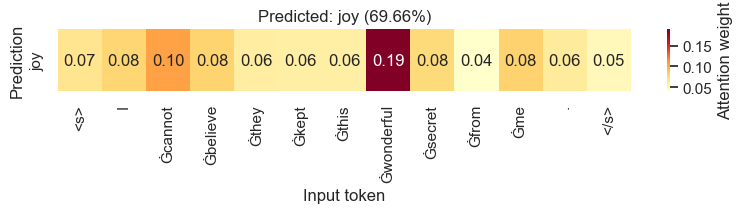

,emotion,probability
3,joy,0.696619
5,surprise,0.199321
0,anger,0.074844
4,sadness,0.028585
2,fear,0.000462
1,disgust,0.000170


In [46]:
def prepare_custom_text(text):
    encoded = custom_tokenizer(
        text,
        truncation=True,
        max_length=CUSTOM_HYPERPARAMS['max_sequence_length'],
        add_special_tokens=True,
    )
    token_ids = encoded['input_ids']
    if not token_ids:
        token_ids = [UNK_ID]
    tokens = custom_tokenizer.convert_ids_to_tokens(token_ids)
    length = len(token_ids)
    token_ids += [PAD_ID] * (
        CUSTOM_HYPERPARAMS['max_sequence_length'] - length
    )
    return tokens, torch.tensor(
        [token_ids],
        dtype=torch.long,
        device=DEVICE,
    ), torch.tensor([length], dtype=torch.long)

def plot_attention_heatmap(text):
    bilstm_attention_model.eval()
    tokens, input_ids, lengths = prepare_custom_text(text)

    with torch.inference_mode():
        logits, attention_weights = bilstm_attention_model(
            input_ids,
            lengths,
            return_attention=True,
        )
        probabilities = torch.softmax(logits, dim=1)[0].cpu().numpy()
        prediction_id = int(np.argmax(probabilities))
        token_weights = attention_weights[0, :len(tokens)].cpu().numpy()

    plt.figure(figsize=(max(8, len(tokens) * 0.55), 2.3))
    sns.heatmap(
        token_weights.reshape(1, -1),
        annot=True,
        fmt='.2f',
        cmap='YlOrRd',
        xticklabels=tokens,
        yticklabels=[id2label[prediction_id]],
        cbar_kws={'label': 'Attention weight'},
    )
    plt.title(
        f'Predicted: {id2label[prediction_id]} '
        f'({probabilities[prediction_id]:.2%})'
    )
    plt.xlabel('Input token')
    plt.ylabel('Prediction')
    plt.tight_layout()
    plt.show()

    return pd.DataFrame({
        'emotion': TARGET_EMOTIONS,
        'probability': probabilities,
    }).sort_values('probability', ascending=False)

attention_examples = [
    'I was thrilled when everyone arrived for my birthday.',
    'The strange noise outside made me extremely nervous.',
    'I cannot believe they kept this wonderful secret from me.',
]

for example_text in attention_examples:
    print(f'\nText: {example_text}')
    display(plot_attention_heatmap(example_text))

## 9. DistilBERT Tokenization and Label Alignment

In [47]:
TRANSFORMER_MODEL_NAME = TRANSFORMER_HYPERPARAMS['base_model']
tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL_NAME)

def tokenize_transformer_batch(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=TRANSFORMER_HYPERPARAMS['max_length'],
    )

tokenized_dataset = dataset.map(
    tokenize_transformer_batch,
    batched=True,
    remove_columns=['text', 'id', 'emotion'],
)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 28104
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3527
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3539
    })
})

## 10. Fine-tune DistilBERT with a Dynamic/Rotating Undersampled Trainer

The custom Trainer uses the same rotating undersampling policy as the
recurrent models. Each training epoch is balanced, majority-class examples
rotate across epochs, and validation/test splits are never undersampled.

In [48]:
def compute_transformer_metrics(eval_prediction):
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'macro_precision': precision_score(
            labels,
            predictions,
            labels=list(range(NUM_CLASSES)),
            average='macro',
            zero_division=0,
        ),
        'macro_recall': recall_score(
            labels,
            predictions,
            labels=list(range(NUM_CLASSES)),
            average='macro',
            zero_division=0,
        ),
        'macro_f1': f1_score(
            labels,
            predictions,
            labels=list(range(NUM_CLASSES)),
            average='macro',
            zero_division=0,
        ),
    }


class EpochPrinterCallback(TrainerCallback):
    def on_epoch_begin(self, args, state, control, **kwargs):
        epoch = int(state.epoch or 0) + 1
        print(f'\nDistilBERT | Epoch {epoch}/{int(args.num_train_epochs)}')

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics:
            return
        print(
            'Validation | '
            f'loss: {metrics.get("eval_loss", float("nan")):.4f} | '
            f'accuracy: {metrics.get("eval_accuracy", float("nan")):.4f} | '
            f'macro_f1: {metrics.get("eval_macro_f1", float("nan")):.4f}'
        )


class DynamicUndersampledTrainer(Trainer):
    def __init__(
        self,
        *args,
        sampler_seed=RANDOM_SEED,
        **kwargs,
    ):
        self.sampler_seed = sampler_seed
        super().__init__(*args, **kwargs)

    def _get_train_sampler(self, train_dataset=None):
        train_dataset = train_dataset or self.train_dataset
        label_column = (
            'label'
            if 'label' in train_dataset.column_names
            else 'labels'
        )
        labels = np.asarray(
            train_dataset[label_column],
            dtype=np.int64,
        )
        return make_rotating_undersampler(labels, seed=self.sampler_seed)


transformer_model = AutoModelForSequenceClassification.from_pretrained(
    TRANSFORMER_MODEL_NAME,
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
).to(DEVICE)

training_args = TrainingArguments(
    output_dir=str(CHECKPOINT_DIR / 'distilbert_trainer_outputs'),
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',
    learning_rate=TRANSFORMER_HYPERPARAMS['learning_rate'],
    per_device_train_batch_size=TRANSFORMER_HYPERPARAMS['batch_size'],
    per_device_eval_batch_size=TRANSFORMER_HYPERPARAMS['batch_size'],
    num_train_epochs=TRANSFORMER_HYPERPARAMS['max_epochs'],
    weight_decay=TRANSFORMER_HYPERPARAMS['weight_decay'],
    warmup_ratio=TRANSFORMER_HYPERPARAMS['warmup_ratio'],
    fp16=(
        TRANSFORMER_HYPERPARAMS['mixed_precision_amp']
        and torch.cuda.is_available()
    ),
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    save_total_limit=2,
    disable_tqdm=True,
    report_to='none',
    seed=RANDOM_SEED,
)

transformer_optimizer = torch.optim.AdamW(
    transformer_model.parameters(),
    lr=TRANSFORMER_HYPERPARAMS['learning_rate'],
    weight_decay=TRANSFORMER_HYPERPARAMS['weight_decay'],
)
steps_per_epoch = math.ceil(
    dynamic_undersample_epoch_size
    / TRANSFORMER_HYPERPARAMS['batch_size']
)
total_training_steps = (
    steps_per_epoch * TRANSFORMER_HYPERPARAMS['max_epochs']
)
warmup_steps = int(
    total_training_steps * TRANSFORMER_HYPERPARAMS['warmup_ratio']
)
transformer_scheduler = get_linear_schedule_with_warmup(
    transformer_optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps,
)

trainer = DynamicUndersampledTrainer(
    model=transformer_model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_transformer_metrics,
    callbacks=[EpochPrinterCallback()],
    optimizers=(transformer_optimizer, transformer_scheduler),
    sampler_seed=RANDOM_SEED,
)

transformer_model

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4883.91it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


## 11. Train and Print DistilBERT Output

In [49]:
print('\nTraining DistilBERT')
transformer_train_output = trainer.train()

transformer_test_output = trainer.predict(tokenized_dataset['test'])
transformer_test_labels = transformer_test_output.label_ids
transformer_test_predictions = np.argmax(
    transformer_test_output.predictions,
    axis=1,
)

print('\nDistilBERT test classification report')
print(classification_report(
    transformer_test_labels,
    transformer_test_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=TARGET_EMOTIONS,
    digits=4,
    zero_division=0,
))

transformer_result = {
    'model': 'DistilBERT',
    'accuracy': accuracy_score(
        transformer_test_labels,
        transformer_test_predictions,
    ),
    'macro_precision': precision_score(
        transformer_test_labels,
        transformer_test_predictions,
        labels=list(range(NUM_CLASSES)),
        average='macro',
        zero_division=0,
    ),
    'macro_recall': recall_score(
        transformer_test_labels,
        transformer_test_predictions,
        labels=list(range(NUM_CLASSES)),
        average='macro',
        zero_division=0,
    ),
    'macro_f1': f1_score(
        transformer_test_labels,
        transformer_test_predictions,
        labels=list(range(NUM_CLASSES)),
        average='macro',
        zero_division=0,
    ),
    'confusion_matrix': confusion_matrix(
        transformer_test_labels,
        transformer_test_predictions,
        labels=list(range(NUM_CLASSES)),
    ),
    'labels': transformer_test_labels.tolist(),
    'predictions': transformer_test_predictions.tolist(),
}

transformer_model_dir = CHECKPOINT_DIR / 'distilbert_emotion_model'
transformer_tokenizer_dir = CHECKPOINT_DIR / 'distilbert_emotion_tokenizer'
transformer_model.save_pretrained(transformer_model_dir)
tokenizer.save_pretrained(transformer_tokenizer_dir)

transformer_checkpoint = {
    'model_name': 'DistilBERT',
    'model_state_dict': transformer_model.state_dict(),
    'optimizer_state_dict': transformer_optimizer.state_dict(),
    'scheduler_state_dict': transformer_scheduler.state_dict(),
    'trainer_history': trainer.state.log_history,
    'id2label': id2label,
    'label2id': label2id,
    'hyperparameters': TRANSFORMER_HYPERPARAMS,
    'sampling_hyperparameters': SAMPLING_HYPERPARAMS,
    'test_metrics': {
        key: value
        for key, value in transformer_result.items()
        if key not in {'confusion_matrix', 'labels', 'predictions'}
    },
}
torch.save(
    transformer_checkpoint,
    CHECKPOINT_DIR / 'DistilBERT_best.pt',
)

{
    key: value
    for key, value in transformer_result.items()
    if key not in {'confusion_matrix', 'labels', 'predictions'}
}


Training DistilBERT

DistilBERT | Epoch 1/100
{'loss': '1.795', 'grad_norm': '1.678', 'learning_rate': '1.98e-06', 'epoch': '1'}
{'eval_loss': '1.838', 'eval_accuracy': '0.03799', 'eval_macro_precision': '0.1138', 'eval_macro_recall': '0.1504', 'eval_macro_f1': '0.04279', 'eval_runtime': '0.7252', 'eval_samples_per_second': '4864', 'eval_steps_per_second': '153.1', 'epoch': '1'}
Validation | loss: 1.8383 | accuracy: 0.0380 | macro_f1: 0.0428


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.56it/s]



DistilBERT | Epoch 2/100
{'loss': '1.777', 'grad_norm': '1.972', 'learning_rate': '3.98e-06', 'epoch': '2'}
{'eval_loss': '1.748', 'eval_accuracy': '0.3904', 'eval_macro_precision': '0.3197', 'eval_macro_recall': '0.3541', 'eval_macro_f1': '0.2915', 'eval_runtime': '0.7333', 'eval_samples_per_second': '4810', 'eval_steps_per_second': '151.4', 'epoch': '2'}
Validation | loss: 1.7476 | accuracy: 0.3904 | macro_f1: 0.2915


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.51it/s]



DistilBERT | Epoch 3/100
{'loss': '1.661', 'grad_norm': '4.058', 'learning_rate': '5.98e-06', 'epoch': '3'}
{'eval_loss': '1.443', 'eval_accuracy': '0.6308', 'eval_macro_precision': '0.4649', 'eval_macro_recall': '0.5506', 'eval_macro_f1': '0.4607', 'eval_runtime': '0.7279', 'eval_samples_per_second': '4845', 'eval_steps_per_second': '152.5', 'epoch': '3'}
Validation | loss: 1.4428 | accuracy: 0.6308 | macro_f1: 0.4607


...

{'train_runtime': '476.5', 'train_samples_per_second': '5898', 'train_steps_per_second': '20.57', 'train_loss': '0.2455', 'epoch': '100'}


There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



DistilBERT test classification report
              precision    recall  f1-score   support

       anger     0.6499    0.7406    0.6922       609
     disgust     0.5190    0.5325    0.5256        77
        fear     0.6559    0.7176    0.6854        85
         joy     0.9155    0.8833    0.8991      1937
     sadness     0.6833    0.6443    0.6632       298
    surprise     0.7457    0.7317    0.7386       533

    accuracy                         0.8042      3539
   macro avg     0.6949    0.7083    0.7007      3539
weighted avg     0.8098    0.8042    0.8062      3539



Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.10it/s]


{'model': 'DistilBERT',
 'accuracy': 0.8041819723085617,
 'macro_precision': 0.694865326748135,
 'macro_recall': 0.7083333719370665,
 'macro_f1': 0.7007064022593624}

## 12. Evaluation, Confusion Matrices, and Model Comparison

In [50]:
model_results = custom_results + [transformer_result]
comparison_df = pd.DataFrame([
    {
        key: value
        for key, value in result.items()
        if key not in {'confusion_matrix', 'labels', 'predictions'}
    }
    for result in model_results
]).sort_values('macro_f1', ascending=False).reset_index(drop=True)

comparison_df

,model,accuracy,macro_precision,macro_recall,macro_f1
0,DistilBERT,0.804182,0.694865,0.708333,0.700706
1,BiLSTM_Attention,0.737214,0.616652,0.679001,0.643437
2,GRU,0.702176,0.583560,0.656564,0.611156
3,LSTM,0.712066,0.585401,0.654815,0.608415


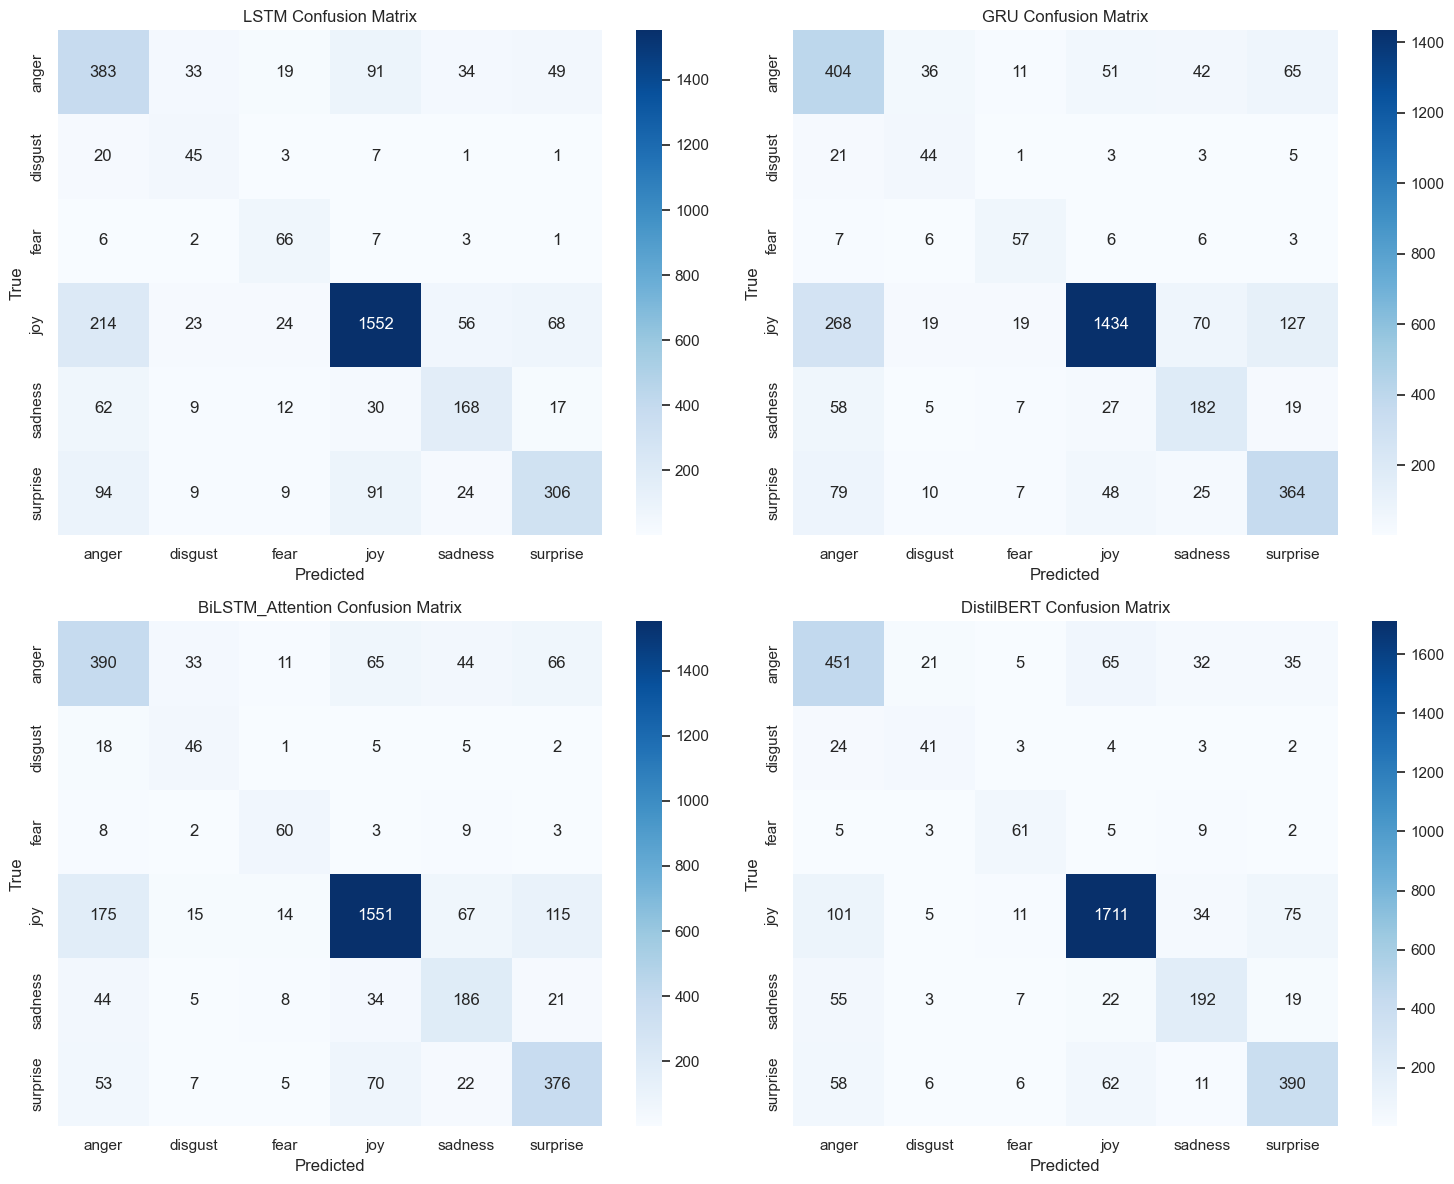

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for axis, result in zip(axes.flat, model_results):
    sns.heatmap(
        result['confusion_matrix'],
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=TARGET_EMOTIONS,
        yticklabels=TARGET_EMOTIONS,
        ax=axis,
    )
    axis.set_title(f'{result["model"]} Confusion Matrix')
    axis.set_xlabel('Predicted')
    axis.set_ylabel('True')

plt.tight_layout()
plt.show()

In [52]:
full_comparison_checkpoint = {
    'results': [
        {
            key: value
            for key, value in result.items()
            if key not in {'labels', 'predictions'}
        }
        for result in model_results
    ],
    'custom_histories': {
        'LSTM': lstm_history,
        'GRU': gru_history,
        'BiLSTM_Attention': attention_history,
    },
    'transformer_history': trainer.state.log_history,
    'id2label': id2label,
    'label2id': label2id,
    'custom_hyperparameters': CUSTOM_HYPERPARAMS,
    'transformer_hyperparameters': TRANSFORMER_HYPERPARAMS,
    'sampling_hyperparameters': SAMPLING_HYPERPARAMS,
}
comparison_checkpoint_path = (
    CHECKPOINT_DIR / 'emotion_model_comparison_checkpoint.pt'
)
torch.save(full_comparison_checkpoint, comparison_checkpoint_path)
comparison_checkpoint_path

WindowsPath('D:/NLP_INSTANT/Emotion Classification Project/checkpoints/emotion_model_comparison_checkpoint.pt')

## 13. Test the Best Model on New Text

In [ ]:
model_registry = {
    'LSTM': lstm_model,
    'GRU': gru_model,
    'BiLSTM_Attention': bilstm_attention_model,
}

def predict_custom_emotion(text, model):
    _, input_ids, lengths = prepare_custom_text(text)
    model.eval()
    with torch.inference_mode():
        logits = model(input_ids, lengths)
        probabilities = torch.softmax(logits, dim=1)[0].cpu().numpy()
    return probabilities

def predict_transformer_emotion(text):
    encoded = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=TRANSFORMER_HYPERPARAMS['max_length'],
    )
    encoded = {key: value.to(DEVICE) for key, value in encoded.items()}
    transformer_model.eval()
    with torch.inference_mode():
        logits = transformer_model(**encoded).logits
        probabilities = torch.softmax(logits, dim=1)[0].cpu().numpy()
    return probabilities

def predict_with_best_model(text):
    best_model_name = comparison_df.iloc[0]['model']
    if best_model_name == 'DistilBERT':
        probabilities = predict_transformer_emotion(text)
    else:
        probabilities = predict_custom_emotion(
            text,
            model_registry[best_model_name],
        )

    probability_table = pd.DataFrame({
        'emotion': TARGET_EMOTIONS,
        'probability': probabilities,
    }).sort_values('probability', ascending=False).reset_index(drop=True)
    return best_model_name, probability_table

test_text = 'I was shocked when my friends suddenly appeared at the door.'
best_model_name, test_probabilities = predict_with_best_model(test_text)

print(f'Best model: {best_model_name}')
print(f'Text: {test_text}')
print(f'Prediction: {test_probabilities.iloc[0]["emotion"]}')
test_probabilities

Best model: DistilBERT
Text: I was shocked when my friends suddenly appeared at the door.
Prediction: surprise


,emotion,probability
0,surprise,0.985952
1,joy,0.007248
2,anger,0.002405
3,sadness,0.002397
4,fear,0.001604
5,disgust,0.000394


: 

## 14. Project Summary

- GoEmotions is mapped to six Ekman classes using the official mapping.
- Cross-class multi-label and neutral examples are excluded.
- Deterministic stratification preserves emotion proportions across the
  training and validation splits while leaving the official test split
  untouched.
- LSTM, GRU, and BiLSTM + Attention use pre-trained GloVe vectors.
- A dynamic rotating undersampler addresses class imbalance by building
  balanced training epochs and rotating majority-class examples across epochs.
- DistilBERT is fine-tuned with a custom Hugging Face Trainer that applies
  the same rotating undersampling policy.
- Every model is evaluated with accuracy, macro F1, per-class
  precision/recall/F1, and a confusion matrix.
- Attention heatmaps show which input words influence the
  BiLSTM + Attention prediction.
- Model weights, optimizer states, histories, mappings, sampling settings,
  and hyperparameters are saved in `checkpoints/`.